In [ ]:
#Import libraries
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


In [ ]:
#Read file
df = pd.read_csv("../../data/raw/Customers.csv")

In [19]:
#Remove CustomerID from dataframe since no predictive power.  Renamed column names to snake case for easier reference in code
df = df.drop(columns=["CustomerID"]).rename(
    columns = {
        'Gender': 'gender',
        'Age': 'age',
        'Annual Income': 'annual_income',
        'Spending Score': 'spending_score',
        'Profession': 'profession',
        'Work Experience': 'work_experience',
        'Family Size': 'family_size',
    }
)

In [ ]:
# Select features for segmentation
X = df[["annual_income", "spending_score"]]

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

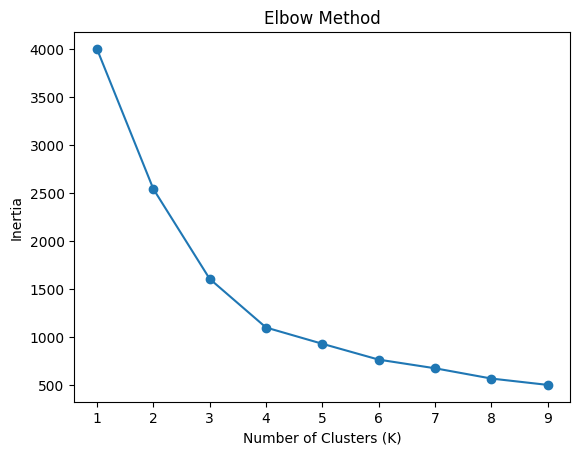

In [ ]:
#Find optimal K using KMeans clustering
inertia = []

for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 10), inertia, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [23]:
#Use Silhouette score to measure how well each data point fits within its assigned cluster compared to other clusters. 
from sklearn.metrics import silhouette_score

X = df[["annual_income", "spending_score"]]

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

for k in range(2, 9):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"K = {k}, Silhouette Score = {score:.4f}")

K = 2, Silhouette Score = 0.3449
K = 3, Silhouette Score = 0.3737
K = 4, Silhouette Score = 0.3819
K = 5, Silhouette Score = 0.3664
K = 6, Silhouette Score = 0.3627
K = 7, Silhouette Score = 0.3531
K = 8, Silhouette Score = 0.3584


In [ ]:
#Fit model using k=4
kmeans = KMeans(n_clusters=4, random_state=42)
df["cluster"] = kmeans.fit_predict(X_scaled)

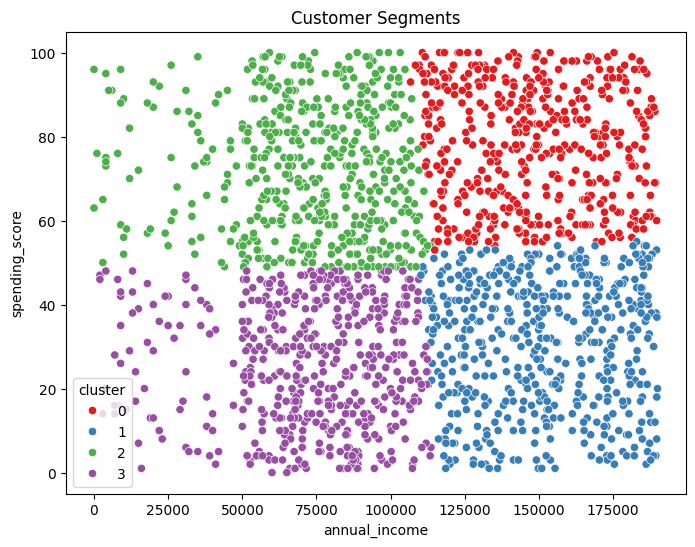

In [ ]:
#Cluster visual
plt.figure(figsize=(8,6))
sns.scatterplot(
    x="annual_income",
    y="spending_score",
    hue="cluster",
    palette="Set1",
    data=df
)
plt.title("Customer Segments")
plt.show()

This cluster shows Spending is not driven by Income
1. High Income and High Spending (Red)
2. High Income and Low Spending (Blue)
3. Moderate Income and High Spendign (Green)
4. Moderate Income and Low Spending (Purple)



In [ ]:
#Segment analysis useing Age and annual income
X = df[["age", "annual_income", "spending_score"]]

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
#Use 4 clusters to fit model
kmeans = KMeans(n_clusters=4, random_state=42)
df["cluster_3d"] = kmeans.fit_predict(X_scaled)

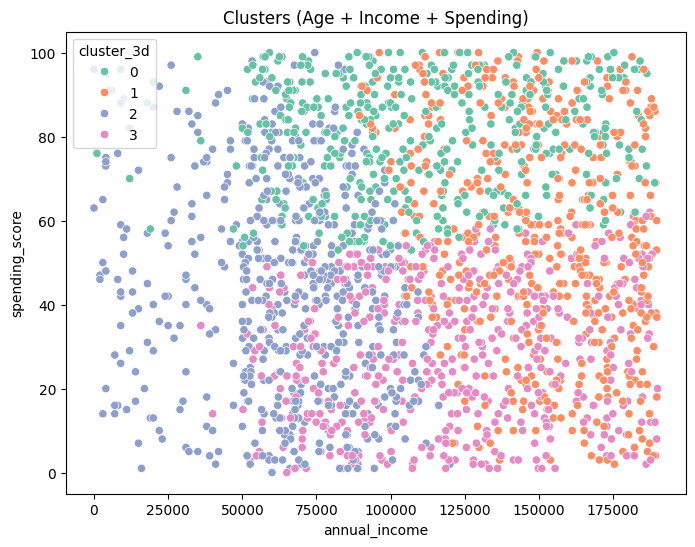

In [ ]:
#visualize cluster
plt.figure(figsize=(8,6))
sns.scatterplot(
    x="annual_income",
    y="spending_score",
    hue="cluster_3d",
    palette="Set2",
    data=df
)
plt.title("Clusters (Age + Income + Spending)")
plt.show()

##After adding age clusters don't show clear separation like before. So Age does not create any additional strength.